In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

In [3]:
# --- Configuration ---
DATA_PATH = '~/gcs-buckets/National_Income_per_capita_till_2023/'
FILE_PATH = os.path.join(DATA_PATH, 'national_income_per_capita_2023.csv')
FORECAST_HORIZON = 6 # years
TARGET_COLUMN = 'Income_Per_Capita' # Adjust if your column name is different
DATE_COLUMN = 'Year' # Adjust if your column name is different (e.g., 'Date')

In [4]:
# --- 1. Load Data ---
df = pd.read_csv(FILE_PATH)
columns = ["country"] + [str(1970 + i) for i in range(52)]
df = df[columns]
df.head()

,country,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21395.334635,21530.677930,22415.993250,23278.822727,23167.712306,23716.237874,24187.066461,26027.017124,20584.791260,24724.866572
1,Africa Eastern and Southern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1326.057821,1310.155272,1326.712853,1222.007579,1154.554761,1298.116409,1241.674597,1212.689013,1098.092611,1214.873282
2,Afghanistan,147.709169,150.772963,128.296489,135.151413,163.370030,173.577068,183.125316,207.427050,227.638311,...,605.752004,597.356158,575.916815,548.968454,484.890590,497.406029,466.570602,468.403506,475.718084,340.523244
3,Africa Western and Central,195.831756,138.579990,162.296828,193.783381,241.071581,290.188233,348.361406,346.829622,379.711153,...,1451.219388,1642.527119,1797.193227,1553.654158,1366.270211,1286.956899,1382.675005,1412.167673,1374.444860,1393.442318
4,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2865.333338,3185.333640,3486.753100,2371.995619,1206.043537,1500.335741,1506.725371,1327.803449,1100.217496,1231.925133


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 53 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  266 non-null    object 
 1   1970     73 non-null     float64
 2   1971     107 non-null    float64
 3   1972     107 non-null    float64
 4   1973     109 non-null    float64
 5   1974     109 non-null    float64
 6   1975     109 non-null    float64
 7   1976     112 non-null    float64
 8   1977     112 non-null    float64
 9   1978     112 non-null    float64
 10  1979     111 non-null    float64
 11  1980     153 non-null    float64
 12  1981     158 non-null    float64
 13  1982     158 non-null    float64
 14  1983     158 non-null    float64
 15  1984     160 non-null    float64
 16  1985     163 non-null    float64
 17  1986     166 non-null    float64
 18  1987     167 non-null    float64
 19  1988     168 non-null    float64
 20  1989     173 non-null    float64
 21  1990     178 non

In [6]:
df["num_timesteps"] = 0

for i, row in df.iterrows():
    df.at[i, "num_timesteps"] = row[1:].count()

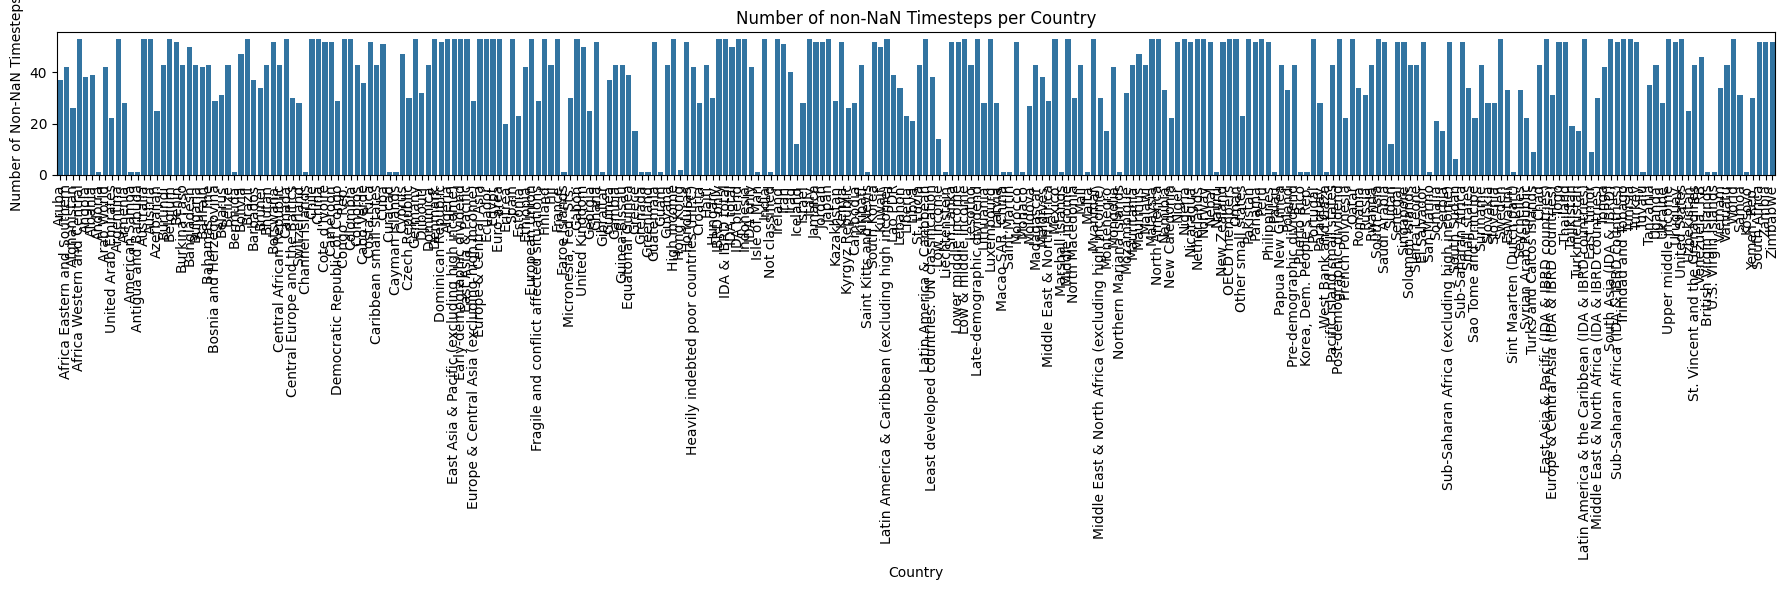

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))
plt.title("Number of non-NaN Timesteps per Country")
sns.barplot(x=df["country"], y=df["num_timesteps"])
# plt.plot(df["num_timesteps"])
plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Number of Non-NaN Timesteps")
plt.tight_layout()
plt.show()

In [8]:
country = "United Kingdom"
df1 = df[df["country"] == country].drop(columns=["country","num_timesteps"]).T.reset_index()
df1.rename(columns={df1.columns[0]: DATE_COLUMN, df1.columns[1]: TARGET_COLUMN}, inplace=True)
df1

,Year,Income_Per_Capita
0,1970,2267.450040
1,1971,2534.270487
2,1972,2881.707738
3,1973,3246.470747
4,1974,3456.507280
5,1975,4064.554993
6,1976,3891.152906
7,1977,4308.658951
8,1978,5473.196929
9,1979,6967.861662


In [9]:
# Convert the date column to datetime objects and set as index
# Assuming 'Year' is an integer, convert it to a string for parsing 'YYYY-01-01'
df1[DATE_COLUMN] = pd.to_datetime(df1[DATE_COLUMN].astype(str) + '-01-01')
df1.set_index(DATE_COLUMN, inplace=True)
df1 = df1.sort_index()

# Ensure the frequency is set for time series operations (Year Start)
df1 = df1.asfreq('YS')

print("Data Head:")
df1.head()

Data Head:


,Income_Per_Capita
Year,
1970-01-01,2267.450040
1971-01-01,2534.270487
1972-01-01,2881.707738
1973-01-01,3246.470747
1974-01-01,3456.507280


In [10]:
print("Data Info:")
df1.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52 entries, 1970-01-01 to 2021-01-01
Freq: YS-JAN
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Income_Per_Capita  49 non-null     float64
dtypes: float64(1)
memory usage: 832.0 bytes


In [11]:
print("Data Description:")
df1.describe()

Data Description:


,Income_Per_Capita
count,49.000000
mean,20080.320370
std,13042.661217
min,2267.450040
25%,7601.090534
50%,17960.752838
75%,34106.744384
max,42710.970880


In [12]:
# Check for missing values
print("Missing values per column:")
print(df1.isnull().sum())
# Handle missing values if any (e.g., df.fillna(method='ffill', inplace=True))
# For annual income, it's less likely to have internal missing values, but good to check.

Missing values per column:
Income_Per_Capita    3
dtype: int64


--- Performing EDA ---


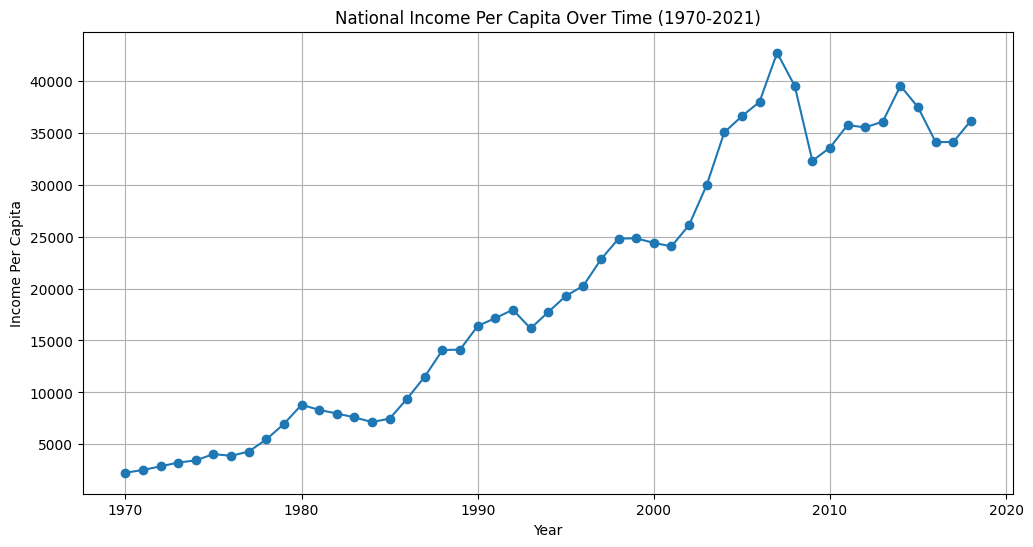

In [13]:
# --- 2. Exploratory Data Analysis (EDA) ---
print("--- Performing EDA ---")

# Plot time series
plt.figure(figsize=(12, 6))
plt.plot(df1.index, df1[TARGET_COLUMN], marker='o')
plt.title(f'National Income Per Capita Over Time ({df1.index.min().year}-{df1.index.max().year})')
plt.xlabel('Year')
plt.ylabel('Income Per Capita')
plt.grid(True)
plt.savefig('income_time_series.png') # Save plot to VM
plt.show() # Will only show if you run locally or use a display server

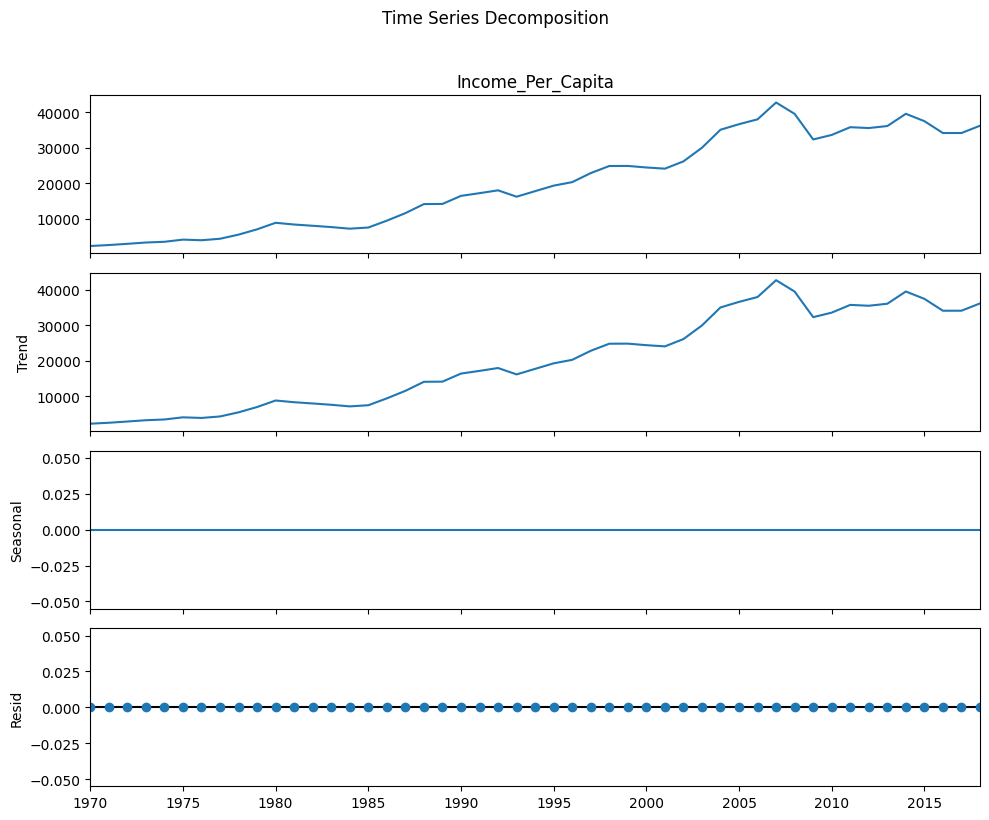

In [14]:
# Time Series Decomposition (Trend, Seasonality, Residuals)
# For annual data, seasonality might not be meaningful or will be represented as a cycle.
# period=1 is often used for annual data to signify no real repeating seasonality within the year.
# However, if there are long term cycles (e.g., business cycles), decompose can show them as trends.
try:
    decomposition = seasonal_decompose(df1[~df1[TARGET_COLUMN].isnull()][TARGET_COLUMN], model='additive', period=1) # period=1 for annual non-seasonal
    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle('Time Series Decomposition', y=1.02)
    plt.tight_layout()
    plt.savefig('time_series_decomposition.png')
    plt.show()
except Exception as e:
    print(f"Could not perform decomposition (e.g., not enough data points for period): {e}")

In [15]:
# Stationarity Check (Augmented Dickey-Fuller Test)
print("--- ADF Test for Stationarity ---")
result = adfuller(df1[~df1[TARGET_COLUMN].isnull()][TARGET_COLUMN])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

if result[1] > 0.05:
    print("Series is likely non-stationary. Consider differencing.")
else:
    print("Series is likely stationary.")

# If non-stationary, apply differencing and re-check (e.g., df[TARGET_COLUMN].diff().dropna())
# For auto_arima, it will handle differencing automatically.

--- ADF Test for Stationarity ---
ADF Statistic: -0.5917904328111152
p-value: 0.8728262831679074
Critical Values:
	1%: -3.5925042342183704
	5%: -2.931549768951162
	10%: -2.60406594375338
Series is likely non-stationary. Consider differencing.


In [16]:
# --- 3. Train-Test Split ---
print("--- Performing Train-Test Split ---")
# Split data into training and testing sets
# Test set will be the last `FORECAST_HORIZON` years (2014-2019)
train_data = df1[~df1["Income_Per_Capita"].isnull()].iloc[:-FORECAST_HORIZON] # Data from 1970 to 2013
test_data = df1[~df1["Income_Per_Capita"].isnull()].iloc[-FORECAST_HORIZON:]  # Data from 2014 to 2019

print(f"Train data from {train_data.index.min().year} to {train_data.index.max().year}")
print(f"Test data from {test_data.index.min().year} to {test_data.index.max().year}")


--- Performing Train-Test Split ---
Train data from 1970 to 2012
Test data from 2013 to 2018


In [17]:
# --- 4. Model Training ---

# Model 1: Auto ARIMA
print("\n--- Training Auto ARIMA Model ---")
# auto_arima automatically finds the best ARIMA(p,d,q)(P,D,Q)s model
# D=0, s=0 because we expect no explicit seasonality for annual data.
# suppress_warnings=True is good for clean output.
# stepwise=True for faster execution by greedily searching.
arima_model = auto_arima(train_data[TARGET_COLUMN],
                         start_p=1, start_q=1,
                         test='adf',       # ADF test to determine 'd'
                         max_p=5, max_q=5, # Maximum p and q to consider
                         m=1,              # Period for seasonality (1 for annual data, no seasonality)
                         d=None,           # Let model determine 'd'
                         seasonal=False,   # No seasonality for annual data
                         trace=True,       # Print fitting progress
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

print("Best Auto ARIMA Model Parameters:")
print(arima_model.summary())

# Model 2: Facebook Prophet
print("\n--- Training Prophet Model ---")
# Prophet requires specific column names: 'ds' for date and 'y' for value.
prophet_df_train = train_data.reset_index()
prophet_df_train.rename(columns={DATE_COLUMN: 'ds', TARGET_COLUMN: 'y'}, inplace=True)

prophet_model = Prophet(
    growth='linear', # or 'logistic' if you know there's a saturation point
    seasonality_mode='additive', # or 'multiplicative'
    yearly_seasonality=False, # No yearly seasonality for purely annual data
    weekly_seasonality=False,
    daily_seasonality=False
)
# Add custom yearly seasonality if you expect some cyclic behaviour but not strict 'seasonal'
# prophet_model.add_seasonality(name='annual_cycle', period=1, fourier_order=5) # Example for annual cycle
prophet_model.fit(prophet_df_train)

print("Prophet Model fitted.")


--- Training Auto ARIMA Model ---
Performing stepwise search to minimize aic


/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation

 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=757.451, Time=0.65 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=760.557, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=759.780, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=756.231, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=764.828, Time=0.02 sec


/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation

 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=757.225, Time=0.20 sec


...

 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=756.865, Time=0.20 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 1.870 seconds
Best Auto ARIMA Model Parameters:


/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
02:35:36 - cmdstanpy - INFO - Chain [1] start processing


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   43
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -375.115
Date:                Thu, 10 Jul 2025   AIC                            756.231
Time:                        02:35:36   BIC                            761.444
Sample:                    01-01-1970   HQIC                           758.142
                         - 01-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    547.9597    499.407      1.097      0.273    -430.859    1526.779
ma.L1          0.5243      0.093      5.659      0.000       0.343       0.706
sigma2       3.64e+06      7e+05      5.197      0.0

02:35:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model fitted.


/home/asudarshan14/EpiCoV_Summer25/epicov/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- Evaluating Auto ARIMA Model ---
Auto ARIMA MAE: 2268.43
Auto ARIMA RMSE: 2612.36


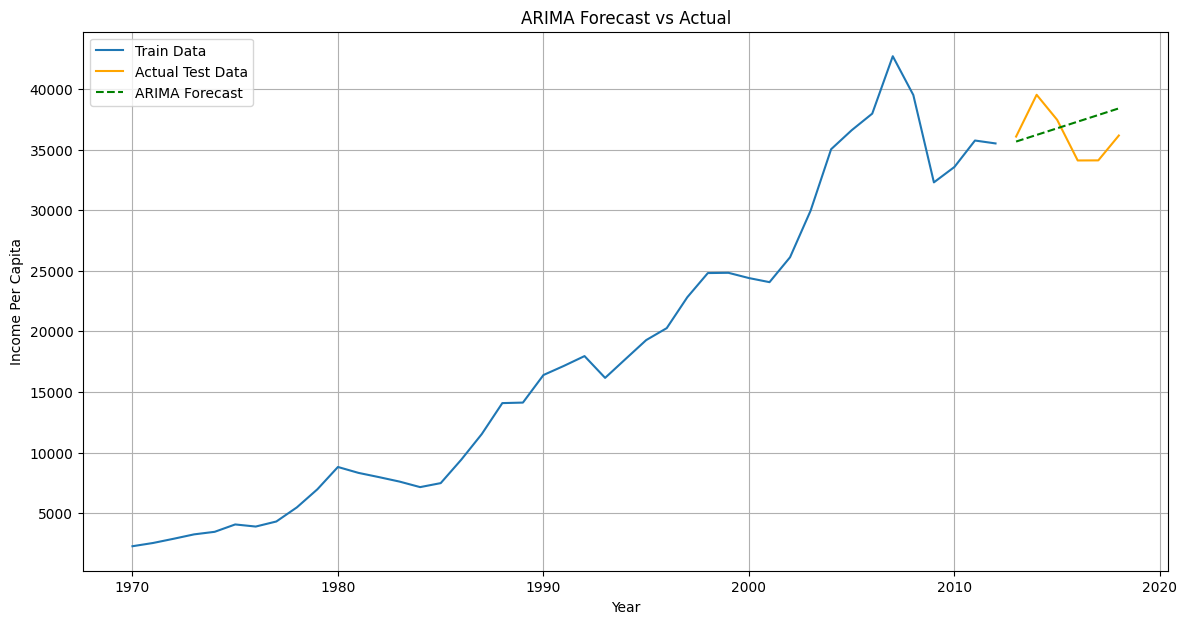


--- Evaluating Prophet Model ---
Prophet MAE: 5781.77
Prophet RMSE: 6575.21


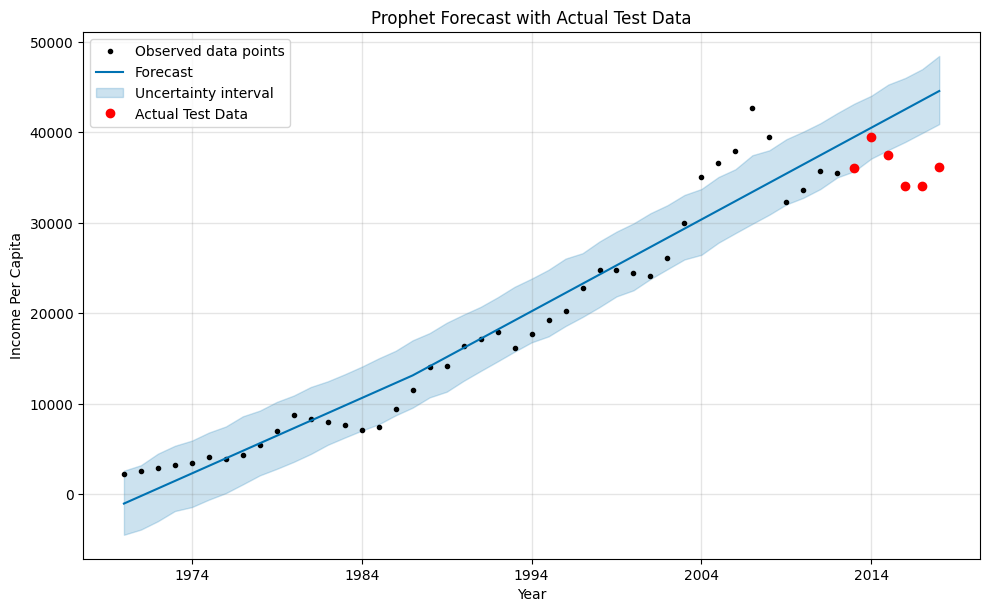

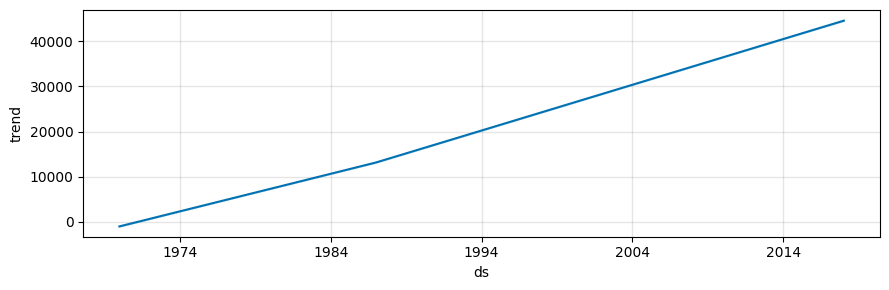

In [18]:
# --- 5. Evaluation ---

# Forecast with Auto ARIMA
print("\n--- Evaluating Auto ARIMA Model ---")
arima_forecast = arima_model.predict(n_periods=FORECAST_HORIZON)
arima_forecast_series = pd.Series(arima_forecast, index=test_data.index)

# Evaluate ARIMA
arima_mae = mean_absolute_error(test_data[TARGET_COLUMN], arima_forecast_series)
arima_rmse = np.sqrt(mean_squared_error(test_data[TARGET_COLUMN], arima_forecast_series))
print(f'Auto ARIMA MAE: {arima_mae:.2f}')
print(f'Auto ARIMA RMSE: {arima_rmse:.2f}')

# Plot ARIMA forecast vs actual
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data[TARGET_COLUMN], label='Train Data')
plt.plot(test_data.index, test_data[TARGET_COLUMN], label='Actual Test Data', color='orange')
plt.plot(arima_forecast_series.index, arima_forecast_series, label='ARIMA Forecast', color='green', linestyle='--')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Year')
plt.ylabel('Income Per Capita')
plt.legend()
plt.grid(True)
plt.savefig('arima_forecast_vs_actual.png')
plt.show()

# Forecast with Prophet
print("\n--- Evaluating Prophet Model ---")
# Create future dataframe for Prophet predictions
future = prophet_model.make_future_dataframe(periods=FORECAST_HORIZON, freq='YS')
prophet_forecast = prophet_model.predict(future)

# Filter Prophet forecast to just the test period
prophet_forecast_test = prophet_forecast[prophet_forecast['ds'].isin(test_data.index)]
prophet_forecast_test_values = prophet_forecast_test['yhat']

# Evaluate Prophet
prophet_mae = mean_absolute_error(test_data[TARGET_COLUMN], prophet_forecast_test_values)
prophet_rmse = np.sqrt(mean_squared_error(test_data[TARGET_COLUMN], prophet_forecast_test_values))
print(f'Prophet MAE: {prophet_mae:.2f}')
print(f'Prophet RMSE: {prophet_rmse:.2f}')

# Plot Prophet forecast vs actual
fig_prophet = prophet_model.plot(prophet_forecast)
ax = fig_prophet.gca()
ax.plot(test_data.index, test_data[TARGET_COLUMN], 'ro', label='Actual Test Data') # Plot actual test points
ax.set_title('Prophet Forecast with Actual Test Data')
ax.set_xlabel('Year')
ax.set_ylabel('Income Per Capita')
plt.legend()
plt.savefig('prophet_forecast_vs_actual.png')
plt.show()
prophet_model.plot_components(prophet_forecast).savefig('prophet_components.png')

Let's try TimesFM through BigQuery ML

In [19]:
from google.cloud import bigquery

client = bigquery.Client()

In [ ]:
# --- 6. TimesFM through BigQuery ML ---
print("\n--- Training TimesFM Model through BigQuery ML ---")

# Set up BigQuery configuration
PROJECT_ID = client.project  # Use the default project from the client
DATASET_ID = 'timesfm_forecasting'
TABLE_ID = 'income_data'
MODEL_ID = 'timesfm_income_model'

# Create dataset if it doesn't exist
dataset_ref = client.dataset(DATASET_ID)
try:
    client.get_dataset(dataset_ref)
    print(f"Dataset {DATASET_ID} already exists")
except Exception:
    dataset = bigquery.Dataset(dataset_ref)
    dataset.location = "US"  # or your preferred location
    client.create_dataset(dataset)
    print(f"Created dataset {DATASET_ID}")

# Prepare data for BigQuery - TimesFM expects specific format
# We need to create a table with columns: time_series_timestamp, time_series_data, time_series_id
timesfm_data = df1.reset_index()
timesfm_data['time_series_id'] = country  # Use country name as series ID
timesfm_data['time_series_timestamp'] = timesfm_data[DATE_COLUMN]
timesfm_data['time_series_data'] = timesfm_data[TARGET_COLUMN]

# Select only the required columns for TimesFM
timesfm_data = timesfm_data[['time_series_timestamp', 'time_series_data', 'time_series_id']].dropna()

print(f"Prepared data shape: {timesfm_data.shape}")
print("Sample data:")
print(timesfm_data.head())

# Upload data to BigQuery
table_ref = dataset_ref.table(TABLE_ID)
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",  # Overwrite table if it exists
    schema=[
        bigquery.SchemaField("time_series_timestamp", "TIMESTAMP"),
        bigquery.SchemaField("time_series_data", "FLOAT64"),
        bigquery.SchemaField("time_series_id", "STRING"),
    ]
)

# Load data to BigQuery
job = client.load_table_from_dataframe(timesfm_data, table_ref, job_config=job_config)
job.result()  # Wait for job to complete

print(f"Uploaded {job.output_rows} rows to BigQuery table {PROJECT_ID}.{DATASET_ID}.{TABLE_ID}")